In [ ]:
# function for pip installing all the libraries:
def install_libraries():
    %pip install -q -U -r requirements.txt


In [3]:
import torch

torch.mps.empty_cache()  # similar to cuda.empty_cache()

In [1]:
# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA
import turftopic
from turftopic import ClusteringTopicModel, KeyNMF
from sklearn.cluster import HDBSCAN
from turftopic.vectorizers.spacy import TokenCountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon



os.environ["OPENAI_API_KEY"] = "sk-a1sY6cAN-hutzhoijNj55ViTOK_2ma9L1fMISWaitiT3BlbkFJQoS4SbHlO13RCoiiMl4NnjFRj8kH0XffrYQQRklSAA"

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & analyses/venv312/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & analyses/venv312/lib/python3.13/site-packages/turftopic/serialization.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Reading in the data

In [7]:
full_df_with_embeddings_field = pd.read_parquet("data/story_text_field_w_embeddings_jina.parquet")
print(full_df_with_embeddings_field.columns.tolist())

full_df_with_embeddings_field = full_df_with_embeddings_field[full_df_with_embeddings_field['language'] == 'de']


corpus_field = full_df_with_embeddings_field["full_story"].tolist()
user_field = full_df_with_embeddings_field["full_user"].tolist()
ai_field = full_df_with_embeddings_field["full_ai"].tolist()




embeddings_field = np.load("data/story_embeddings_jina_field.npy")
embeddings_user = np.load("data/story_user_embeddings_jina_field.npy")
embeddings_ai = np.load("data/story_ai_embeddings_jina_field.npy")

['conversation_id', 'client_id', 'workshop_id', 'language', 'full_story', 'full_user', 'full_ai', 'embedding_jina', 'user_embedding_jina', 'ai_embedding_jina']


## Checking the embeddings

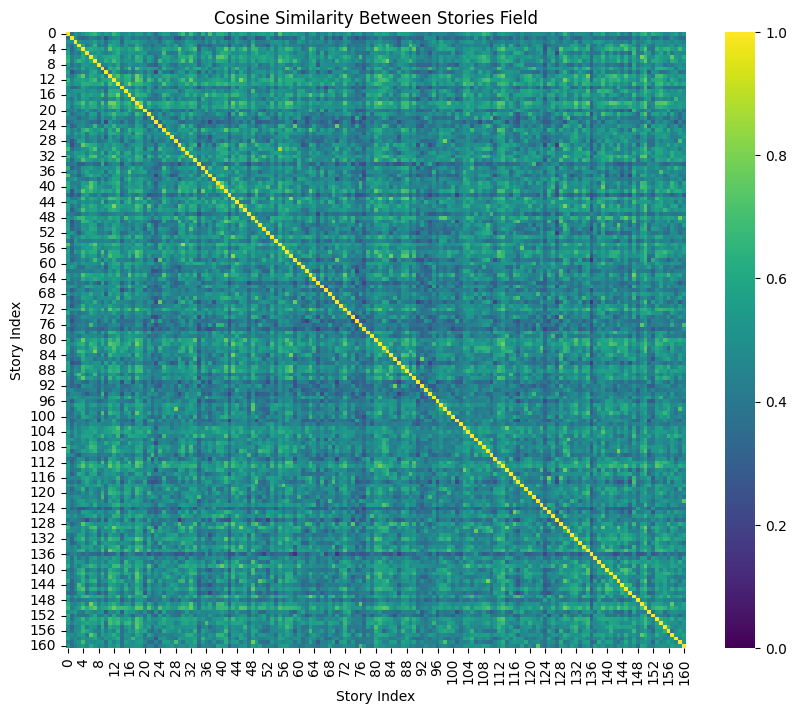

0.021209104 0.4855149


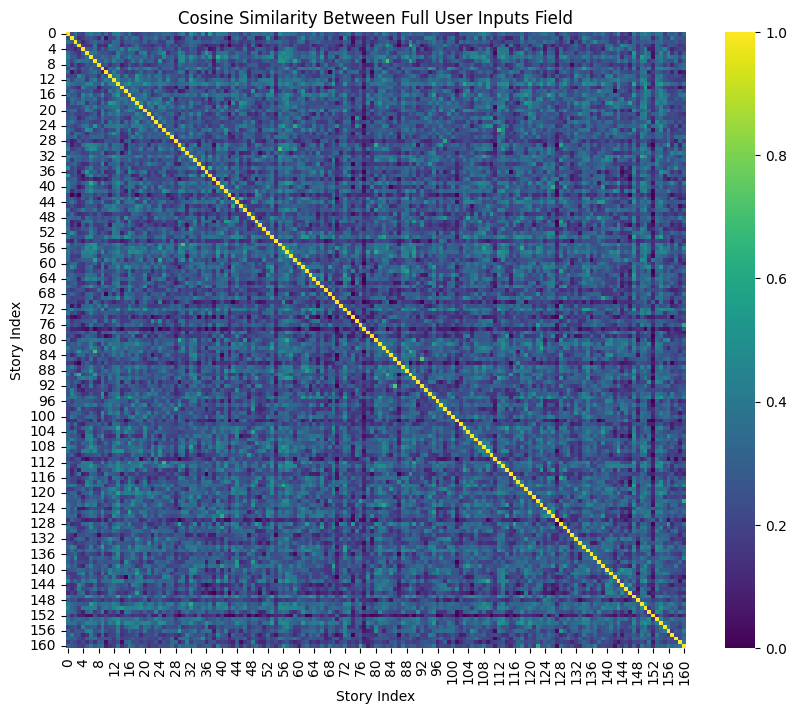

0.02520922 0.2744998


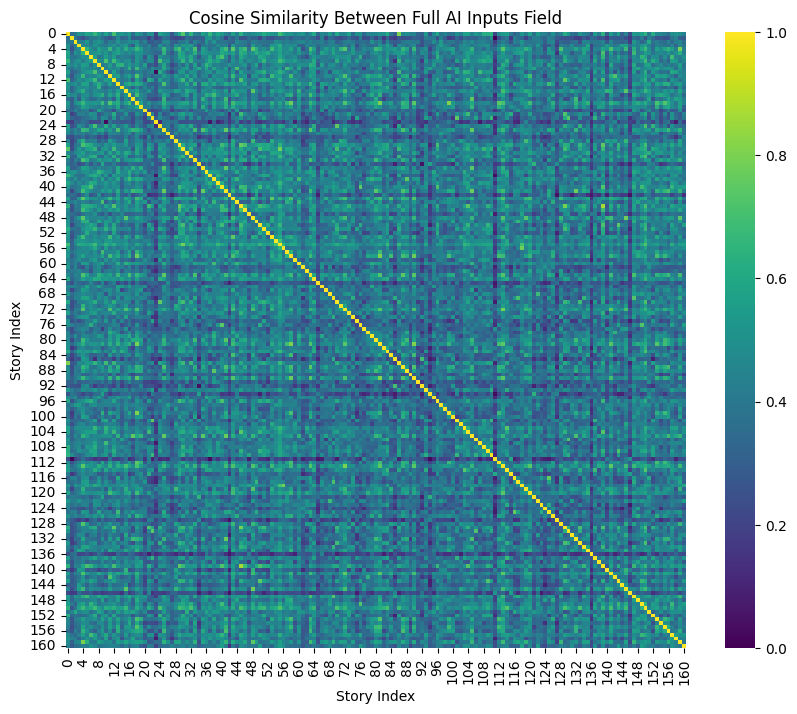

0.022640182 0.41417447


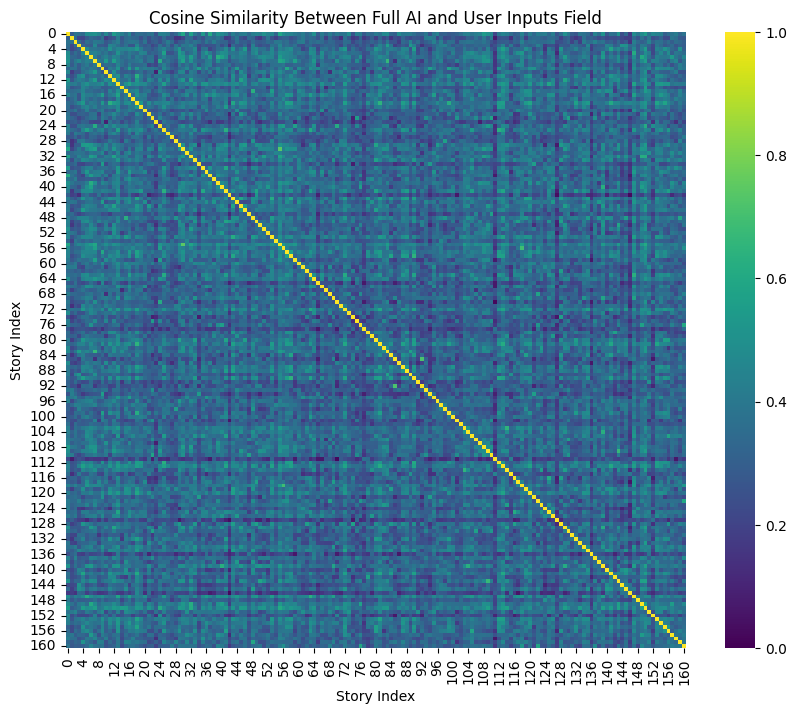

0.0239247 0.3443371


In [8]:
sim_matrix_field = cosine_similarity(embeddings_field)
sim_matrix_field_full_user = cosine_similarity(embeddings_user)
sim_matrix_field_full_ai = cosine_similarity(embeddings_ai)
full_embeddings_ai_user = np.concatenate([full_df_with_embeddings_field["user_embedding_jina"].tolist(), full_df_with_embeddings_field["ai_embedding_jina"].tolist()], axis=1)
sim_matrix_field_full_ai_user = cosine_similarity(full_embeddings_ai_user)


# sim_matrix_field = cosine_similarity(full_df_with_embeddings_field["embedding_jina"].tolist())
# sim_matrix_field_full_user = cosine_similarity(full_df_with_embeddings_field["user_embedding_jina"].tolist())
# sim_matrix_field_full_ai = cosine_similarity(full_df_with_embeddings_field["ai_embedding_jina"].tolist())
# full_embeddings_ai_user = np.concatenate([full_df_with_embeddings_field["user_embedding_jina"].tolist(), full_df_with_embeddings_field["ai_embedding_jina"].tolist()], axis=1)
# sim_matrix_field_full_ai_user = cosine_similarity(full_embeddings_ai_user)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.title("Cosine Similarity Between Stories Field")
plt.show()
print(np.std(embeddings_field, axis=0).mean(), np.mean(sim_matrix_field))  

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_user, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full User Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(embeddings_user, axis=0).mean(), np.mean(sim_matrix_field_full_user))

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_ai, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full AI Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(embeddings_ai, axis=0).mean(), np.mean(sim_matrix_field_full_ai))  #


plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_ai_user, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full AI and User Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(np.concatenate([full_df_with_embeddings_field["user_embedding_jina"].tolist(), full_df_with_embeddings_field["ai_embedding_jina"].tolist()], axis=1), axis=0).mean(), np.mean(sim_matrix_field_full_ai_user))

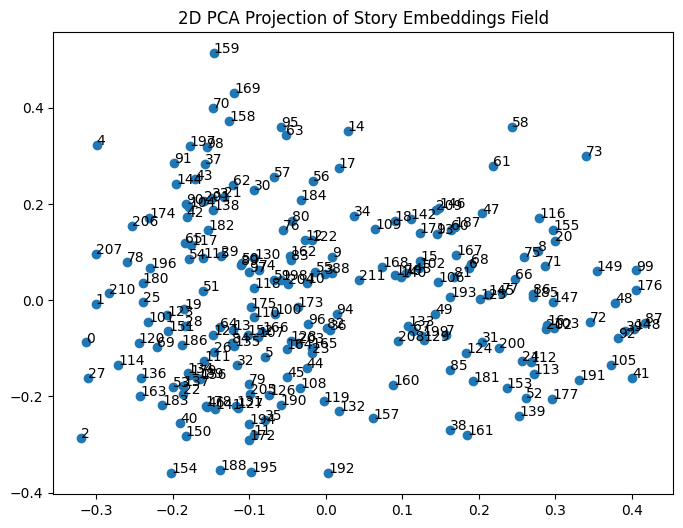

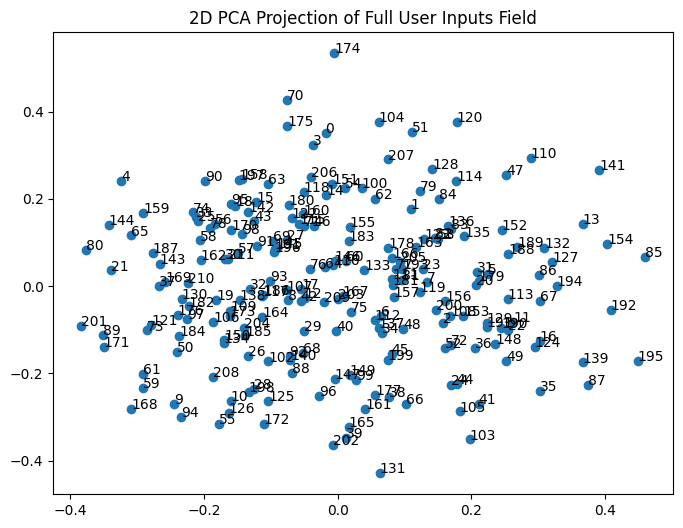

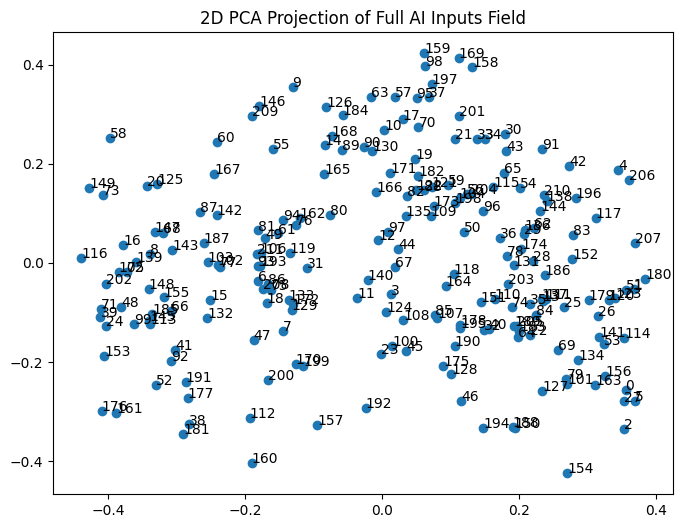

In [7]:
X_2d = PCA(n_components=2).fit_transform(embeddings_field)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
for i, txt in enumerate(range(len(X_2d))):
    plt.annotate(txt, (X_2d[i, 0], X_2d[i, 1]))
plt.title("2D PCA Projection of Story Embeddings Field")
plt.show()

X_2d_field_user = PCA(n_components=2).fit_transform(embeddings_user)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d_field_user[:, 0], X_2d_field_user[:, 1])
for i, txt in enumerate(range(len(X_2d_field_user))):
    plt.annotate(txt, (X_2d_field_user[i, 0], X_2d_field_user[i, 1]))
plt.title("2D PCA Projection of Full User Inputs Field")
plt.show()


X_2d_field_ai = PCA(n_components=2).fit_transform(embeddings_ai)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d_field_ai[:, 0], X_2d_field_ai[:, 1])
for i, txt in enumerate(range(len(X_2d_field_ai))):
    plt.annotate(txt, (X_2d_field_ai[i, 0], X_2d_field_ai[i, 1]))
plt.title("2D PCA Projection of Full AI Inputs Field")
plt.show()


### Loading encoder

In [ ]:
# Load the instructed multilingual E5 with asymmetric prompts per KeyNMF docs
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    prompts={
        "query":   "Instruct: Retrieve relevant keywords from the given document. Query: ",
        "passage": "Passage: "
    },
    # Documents must be encoded as queries; words (terms) use the passage prompt
    default_prompt_name="query",
)

ModuleNotFoundError: No module named 'custom_st'

# Field data E5 topic modelling analysis

### Full story analysis using KeyNMF

In [ ]:
# 2) Fit KeyNMF
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(corpus_field)

# 3) Prepare the TopicData
topic_data_field = model.prepare_topic_data(corpus_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field.figures.topic_barcharts()
topic_data_field.figures.document_map()
topic_data_field.print_topics()

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:41:13] Keyword extraction done.                                                                   keynmf.py:238

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning:

Maximum number of iterations 200 reached. Increase it to improve convergence.

           Model fitting done.                                                                        keynmf.py:245

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:41:34] Keyword extraction done.                                                                   keynmf.py:442

           Model fitting done.                                                                        keynmf.py:453

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name               ┃ Highest Ranking                                                           ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ 0_und_ich_einem_einen    │ und, ich, einem, einen, sehe, spüre, ist, geschichten, durch, diese       │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        1 │ 1_ai_digital_feel_like   │ ai, digital, feel, like, user, human, remember, memories, consciousness,  │
│          │                          │ life                                                                      │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        2 │ 2_sich_hier_ich_werde    │ sich, hier, ich, werde, mehr, diesem, träume, ihnen, dich, jemand         │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        3 │ 3_meine_diese_ich_meinen │ meine, diese, ich, meinen, erinnerungen, ihre, meinem, eigenen, als,      │
│          │                          │ menschen                                                                  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        4 │ 4_mich_ich_hier_einem    │ mich, ich, hier, einem, meiner, erinnere, stehe, sehe, selbst, verstehen  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        5 │ 5_oder_sein_ist_ich      │ oder, sein, ist, ich, wo, mensch, ihr, werde, warum, eigenen              │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        6 │ 6_das_ich_die_selbst     │ das, ich, die, selbst, meinem, neuen, steht, dem, menschen, träumen       │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        7 │ 7_wie_ich_nach_träume    │ wie, ich, nach, träume, ihre, wäre, sehe, wurde, fühle, erzählt           │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        8 │ 8_mein_stehe_ich_meinen  │ mein, stehe, ich, meinen, ist, erzählt, selbst, dieser, erzählen, meinem  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        9 │ 9_über_nach_dieser_ich   │ über, nach, dieser, ich, sprachmodell, meinen, ihnen, zukunft, erzählen,  │
│          │                          │ träumen                                                                   │
└──────────┴──────────────────────────┴───────────────────────────────────────────────────────────────────────────┘

In [ ]:
# transform the corpus to get document-topic distributions
doc_topic_field_story = model.transform(corpus_field)
#normalize the document-topic distribution to a probability distribution
P_field = doc_topic_field_story / doc_topic_field_story.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field = (P_field > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field = entropy(P_field.T)

print(f"Mean breadth field: {breadth_field.mean():.3f}")
print(f"Mean entropy field: {entropy_scores_field.mean():.3f}")

Mean breadth field: 5.028
Mean entropy field: 1.161


In [ ]:
#jensen-shannon divergence within the field corpus
n_f = P_field.shape[0]
js_within_field = []
for i in range(n_f):
    for j in range(i + 1, n_f):
        js_within_field.append(jensenshannon(P_field[i], P_field[j]))

mean_js_within_field = np.mean(js_within_field)
print(f"Mean JS within field: {mean_js_within_field:.3f}")

Mean JS within field: 0.626


### Full user input analysis using E5

In [ ]:
# 2) Fit KeyNMF
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(user_field)

# 3) Prepare the TopicData
topic_data_field_user = model.prepare_topic_data(user_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field_user.figures.topic_barcharts()
topic_data_field_user.figures.document_map()
topic_data_field_user.print_topics()

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:43:29] Keyword extraction done.                                                                   keynmf.py:238

           Model fitting done.                                                                        keynmf.py:245

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:43:39] Keyword extraction done.                                                                   keynmf.py:442

           Model fitting done.                                                                        keynmf.py:453

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                ┃ Highest Ranking                                                  ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ 0_bin_und_meine_für       │ bin, und, meine, für, werde, hat, es, wieder, ein, aber          │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        1 │ 1_mich_meinen_sehe_wieder │ mich, meinen, sehe, wieder, noch, leben, mein, um, ein, etwas    │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        2 │ 2_ich_und_das_der         │ ich, und, das, der, aber, im, aus, ki, meinen, habe              │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        3 │ 3_zu_um_du_wie            │ zu, um, du, wie, sein, sehe, und, wer, stehe, mit                │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        4 │ 4_wir_und_sind_uns        │ wir, und, sind, uns, aus, hier, eine, warum, auf, wird           │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        5 │ 5_mir_sein_wieder_mein    │ mir, sein, wieder, mein, meinem, oder, aus, meiner, einem, einen │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        6 │ 6_sich_wie_mehr_über      │ sich, wie, mehr, über, dich, das, sein, einem, aber, ihre        │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        7 │ 7_ist_es_und_aus          │ ist, es, und, aus, wird, noch, man, sehe, wie, diese             │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        8 │ 8_sie_von_als_und         │ sie, von, als, und, meine, nach, hat, um, mehr, alles            │
├──────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────┤
│        9 │ 9_auf_meine_meinem_schon  │ auf, meine, meinem, schon, es, stehe, immer, werden, nach, mein  │
└──────────┴───────────────────────────┴──────────────────────────────────────────────────────────────────┘

In [ ]:
doc_topic_field_user = model.transform(user_field)
#normalize the document-topic distribution to a probability distribution
P_field_user = doc_topic_field_user / doc_topic_field_user.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field_user = (P_field_user > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field_user = entropy(P_field_user.T)

print(f"Mean breadth field_user: {breadth_field_user.mean():.3f}")
print(f"Mean entropy field_user: {entropy_scores_field_user.mean():.3f}")

Mean breadth field_user: 4.830
Mean entropy field_user: nan


/var/folders/k_/n9gdj4xd2qjb7n7d7399r5dm0000gn/T/ipykernel_77452/3844022526.py:3: RuntimeWarning:

invalid value encountered in divide



In [ ]:
(doc_topic_field_user.sum(axis=1) == 0).sum() 
idx_zero = np.where(doc_topic_field_user.sum(axis=1) == 0)[0]
[user_field[i][:120] for i in idx_zero]
doc_topic_field_user.min()


np.float64(0.0)

In [ ]:
#jensen-shannon divergence within the field corpus
n_f = P_field_user.shape[0]
js_within_field_user = []
for i in range(n_f):
    for j in range(i + 1, n_f):
        js_within_field_user.append(jensenshannon(P_field_user[i], P_field_user[j]))
        
mean_js_within_field_user = np.mean(js_within_field_user)
print(f"Mean JS within field user: {mean_js_within_field_user:.3f}")

Mean JS within field user: nan


### Full AI input analysis using E5

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(ai_field)

# 3) Prepare the TopicData
topic_data_field_ai = model.prepare_topic_data(ai_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field_ai.figures.topic_barcharts()
topic_data_field_ai.figures.document_map()
topic_data_field_ai.print_topics()

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:12:23] Keyword extraction done.                                                                   keynmf.py:238

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning:

Maximum number of iterations 200 reached. Increase it to improve convergence.

           Model fitting done.                                                                        keynmf.py:245

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

/Users/halfidaldal/Documents/PENPAL_analysis/Berlin/Scripts & 
analyses/venv312/lib/python3.13/site-packages/rich/live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

[12:12:32] Keyword extraction done.                                                                   keynmf.py:442

           Model fitting done.                                                                        keynmf.py:453

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name               ┃ Highest Ranking                                                           ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ 0_und_ich_einem_einen    │ und, ich, einem, einen, sehe, spüre, ist, geschichten, durch, diese       │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        1 │ 1_ai_digital_feel_like   │ ai, digital, feel, like, user, human, remember, memories, consciousness,  │
│          │                          │ life                                                                      │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        2 │ 2_sich_hier_ich_werde    │ sich, hier, ich, werde, mehr, diesem, träume, ihnen, dich, jemand         │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        3 │ 3_meine_diese_ich_meinen │ meine, diese, ich, meinen, erinnerungen, ihre, meinem, eigenen, als,      │
│          │                          │ menschen                                                                  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        4 │ 4_mich_ich_hier_einem    │ mich, ich, hier, einem, meiner, erinnere, stehe, sehe, selbst, verstehen  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        5 │ 5_oder_sein_ist_ich      │ oder, sein, ist, ich, wo, mensch, ihr, werde, warum, eigenen              │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        6 │ 6_das_ich_die_selbst     │ das, ich, die, selbst, meinem, neuen, steht, dem, menschen, träumen       │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        7 │ 7_wie_ich_nach_träume    │ wie, ich, nach, träume, ihre, wäre, sehe, wurde, fühle, erzählt           │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        8 │ 8_mein_stehe_ich_meinen  │ mein, stehe, ich, meinen, ist, erzählt, selbst, dieser, erzählen, meinem  │
├──────────┼──────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│        9 │ 9_über_nach_dieser_ich   │ über, nach, dieser, ich, sprachmodell, meinen, ihnen, zukunft, erzählen,  │
│          │                          │ träumen                                                                   │
└──────────┴──────────────────────────┴───────────────────────────────────────────────────────────────────────────┘

In [ ]:
doc_topic_field_ai = model.transform(ai_field)
#normalize the document-topic distribution to a probability distribution
P_field_ai = doc_topic_field_ai / doc_topic_field_ai.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field_ai = (P_field_ai > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field_ai = entropy(P_field_ai.T)

print(f"Mean breadth field: {breadth_field_ai.mean():.3f}")
print(f"Mean entropy field: {entropy_scores_field_ai.mean():.3f}")

Mean breadth field: 5.704
Mean entropy field: 1.290


In [ ]:
# jensen-shannon divergence within the simulated corpus
n_s = P_field_ai.shape[0]
js_within_field_ai = []
for i in range(n_s):
    for j in range(i + 1, n_s):
        js_within_field_ai.append(jensenshannon(P_field_ai[i], P_field_ai[j]))

mean_js_within_field_ai = np.mean(js_within_field_ai)
print(f"Mean JS within field AI: {mean_js_within_field_ai:.3f}")


Mean JS within field AI: 0.483


In [ ]:
#cluster the topic-vectors
model = ClusteringTopicModel(feature_importance="centroid")
model.fit_transform(ai_field)

# Simulated data E5 topic modelling analysis

### Full story analysis using KeyNMF

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(corpus_sim)
# 3) Prepare the TopicData
topic_data_sim = model.prepare_topic_data(corpus_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim.figures.topic_barcharts()
topic_data_sim.figures.document_map()
topic_data_sim.print_topics()

Output()

[17:38:07] Keyword extraction done.                                                                   ]8;id=101483;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=405150;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#228\228]8;;\

           Model fitting done.                                                                        ]8;id=628602;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=948620;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#235\235]8;;\

Output()

[17:38:13] Keyword extraction done.                                                                   ]8;id=381306;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=254402;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#426\426]8;;\

           Model fitting done.                                                                        ]8;id=474636;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=444355;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#437\437]8;;\

In [ ]:
doc_topic_sim_story = model.transform(corpus_sim)
#normalize the document-topic distribution to a probability distribution
P_sim = doc_topic_sim_story / doc_topic_sim_story.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_sim = (P_sim > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_sim = entropy(P_sim.T)

print(f"Mean breadth simulated: {breadth_sim.mean():.3f}")
print(f"Mean entropy simulated: {entropy_scores_sim.mean():.3f}")

Mean breadth simulated: 5.667
Mean entropy simulated: 1.211


In [ ]:
#jensen-shannon divergence within the simulated corpus
n_s = P_sim.shape[0]
js_within_sim = []
for i in range(n_s):
    for j in range(i + 1, n_s):
        js_within_sim.append(jensenshannon(P_sim[i], P_sim[j]))

### Simulated user input analysis

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(user_sim)
# 3) Prepare the TopicData
topic_data_sim_user = model.prepare_topic_data(user_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim_user.figures.topic_barcharts()
topic_data_sim_user.figures.document_map()
topic_data_sim_user.print_topics()

### Simulated AI input analysis

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(ai_sim)
# 3) Prepare the TopicData
topic_data_sim_ai = model.prepare_topic_data(ai_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim_ai.figures.topic_barcharts()
topic_data_sim_ai.figures.document_map()

topic_data_sim_ai.print_topics()

Output()

[19:23:24] Keyword extraction done.                                                                   ]8;id=88928;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=968808;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#228\228]8;;\

/Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/sklearn/decomposition/_
nmf.py:1728: ConvergenceWarning:

Maximum number of iterations 200 reached. Increase it to improve convergence.

           Model fitting done.                                                                        ]8;id=151494;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=550753;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#235\235]8;;\

Output()

[19:23:29] Keyword extraction done.                                                                   ]8;id=499657;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=175239;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#426\426]8;;\

           Model fitting done.                                                                        ]8;id=805950;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py\keynmf.py]8;;\:]8;id=530393;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/keynmf.py#437\437]8;;\

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                               ┃ Highest Ranking                                           ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ 0_næste_gåden_gåde_eventyr               │ næste, gåden, gåde, eventyr, nøglen, magiske, skræmme,    │
│          │                                          │ skyggerne, låsen, hemmeligheder                           │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        1 │ 1_drømme_drøm_skyggerne_eventyr          │ drømme, drøm, skyggerne, eventyr, magiske, skyggen,       │
│          │                                          │ mørket, skabningen, magisk, søger                         │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        2 │ 2_kæmpe_nysgerrige_blevet_skyggerne      │ kæmpe, nysgerrige, blevet, skyggerne, gåde, fandt, søger, │
│          │                                          │ finde, fundet, drage                                      │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        3 │ 3_kæmpe_nøglen_skyggerne_ræven           │ kæmpe, nøglen, skyggerne, ræven, magiske, gåde, søger,    │
│          │                                          │ magisk, hjælpe, skræmmende                                │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        4 │ 4_drage_næste_ræven_skyggerne            │ drage, næste, ræven, skyggerne, magiske, eventyr,         │
│          │                                          │ skræmmende, træerne, mørket, skabningen                   │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        5 │ 5_hemmeligheder_skræmmende_magiske_drage │ hemmeligheder, skræmmende, magiske, drage, skyggerne,     │
│          │                                          │ hemmelig, gåden, kæmpe, mørket, nøglen                    │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        6 │ 6_bogen_magisk_magiske_drage             │ bogen, magisk, magiske, drage, gåde, skabningen, næste,   │
│          │                                          │ hemmeligheder, skyggen, nøgle                             │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        7 │ 7_nøglen_eventyr_gåde_skyggerne          │ nøglen, eventyr, gåde, skyggerne, fundet, magiske, gåden, │
│          │                                          │ hemmeligheder, forsvandt, nøgler                          │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        8 │ 8_fuglen_skræmme_skræmmende_drøm         │ fuglen, skræmme, skræmmende, drøm, eventyr, magiske,      │
│          │                                          │ fløj, bogen, gåde, skyggen                                │
├──────────┼──────────────────────────────────────────┼───────────────────────────────────────────────────────────┤
│        9 │ 9_skabningen_gåde_skabning_skyggerne     │ skabningen, gåde, skabning, skyggerne, magiske, nøglen,   │
│          │                                          │ skabte, drøm, gåden, skræmme                              │
└──────────┴──────────────────────────────────────────┴───────────────────────────────────────────────────────────┘

In [ ]:
doc_topic_sim_ai = model.transform(ai_sim)
#normalize the document-topic distribution to a probability distribution
P_sim_ai = doc_topic_sim_ai / doc_topic_sim_ai.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_sim_ai = (P_sim_ai > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_sim_ai = entropy(P_sim_ai.T)

print(f"Mean breadth simulated AI: {breadth_sim_ai.mean():.3f}")
print(f"Mean entropy simulated AI: {entropy_scores_sim_ai.mean():.3f}")

Mean breadth simulated AI: 4.222
Mean entropy simulated AI: 0.870


In [ ]:
# jensen-shannon divergence within the simulated ai_corpus
n_sa = P_sim_ai.shape[0]
js_within_ai_sim = []
for i in range(n_sa):
    for j in range(i + 1, n_sa):
        js_within_ai_sim.append(jensenshannon(P_sim_ai[i], P_sim_ai[j]))

mean_js_within_ai_sim = np.mean(js_within_ai_sim)
print(f"Mean JS within simulated AI: {mean_js_within_ai_sim:.3f}")


Mean JS within simulated AI: 0.700


In [ ]:
clusterer = HDBSCAN(min_cluster_size=4, min_samples=1)
model = ClusteringTopicModel(
  encoder=l2v,
  dimensionality_reduction=UMAP(metric="cosine"),
  clustering=clusterer,
  feature_importance="centroid"
)
doc_topic = model.fit_transform(ai_sim, embeddings=story_embeddings_ai_sim)

[17:40:17] Term extraction done.                                                                     ]8;id=549640;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=811170;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#481\481]8;;\

Output()

           Dimensionality reduction done.                                                            ]8;id=867532;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=931333;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#490\490]8;;\

           Clustering done.                                                                          ]8;id=302491;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=291281;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#493\493]8;;\

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

[17:59:19] Parameter estimation done.                                                                ]8;id=67950;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=583752;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#512\512]8;;\

           Model fitting done.                                                                       ]8;id=344010;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=718523;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#526\526]8;;\

In [ ]:
model.print_topics()
topics_df = model.topics_df()

# Show interactive cluster map
fig = model.plot_clusters_datamapplot()
fig.show()
# Merge down to 5 top-level topics using "smallest→closest" (Top2Vec’s strategy)
model.reduce_topics(n_reduce_to=5, reduction_method="smallest", metric="cosine")

print(model.hierarchy)
model.hierarchy.cut(max_depth=2).plot_tree()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                  ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ trolden, gåden, skyggerne, trold, gemt, skabte, forsvandt, hule, opdagede, fandt │
├──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│        1 │ trolden, gemt, drejede, feen, skabte, trold, forsvandt, gemte, fandt, gåden      │
└──────────┴──────────────────────────────────────────────────────────────────────────────────┘

/Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:265: UserWarning:

Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.

/Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:284: UserWarning:

Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-

Root: 
├── 0: trolden, gåden, skyggerne, trold, gemt, skabte, forsvandt, hule, opdagede, fandt
└── 1: trolden, gemt, drejede, feen, skabte, trold, forsvandt, gemte, fandt, gåden



In [ ]:
from sklearn.cluster import KMeans
model = ClusteringTopicModel(
    dimensionality_reduction=UMAP(metric="cosine"),
    clustering=KMeans(n_clusters=5, random_state=0),
    feature_importance="centroid"
)
doc_topic = model.fit_transform(ai_sim, embeddings=story_embeddings_ai_sim)

/Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning:

`clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884



[18:28:54] Term extraction done.                                                                     ]8;id=980170;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=415685;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#481\481]8;;\

Output()

[18:28:55] Dimensionality reduction done.                                                            ]8;id=899452;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=920876;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#490\490]8;;\

           Clustering done.                                                                          ]8;id=923655;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=236431;file:///Users/halfidaldal/Documents/NES_paper/topic_modelling/venv312/lib/python3.12/site-packages/turftopic/models/cluster.py#493\493]8;;\

ValueError: Document embedding dimensionality (4096) doesn't match term embedding dimensionality (384). Perhaps you are using precomputed embeddings but forgot to pass an encoder to your model. Try to initialize the model with the encoder you used for computing the embeddings.

# Comparing field vs simulated

### Full story

#### Breadth

/var/folders/k_/n9gdj4xd2qjb7n7d7399r5dm0000gn/T/ipykernel_28995/4159366040.py:1: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



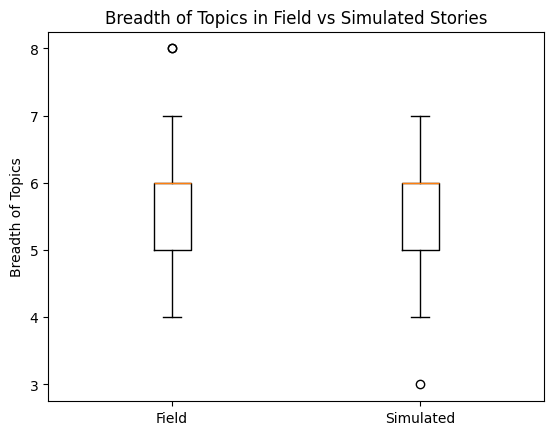

/var/folders/k_/n9gdj4xd2qjb7n7d7399r5dm0000gn/T/ipykernel_28995/4159366040.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



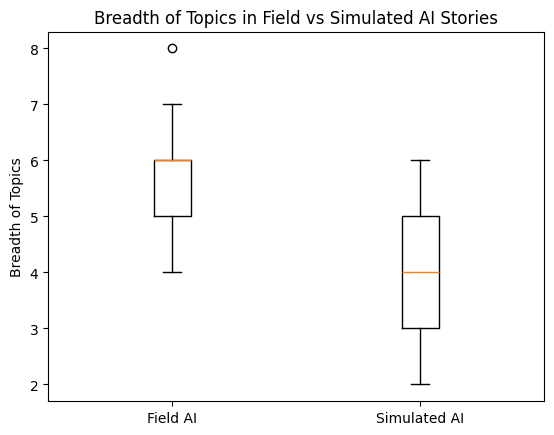

In [ ]:
# Breadth = count of topics with nonzero weight. A story loading on 5 topics is more exploratory than one loading on 1–2

plt.boxplot([breadth_field, breadth_sim], labels=["Field", "Simulated"])
plt.title("Breadth of Topics in Field vs Simulated Stories")
plt.ylabel("Breadth of Topics")
plt.show()

plt.boxplot([breadth_field_ai, breadth_sim_ai], labels=["Field AI", "Simulated AI"])
plt.title("Breadth of Topics in Field vs Simulated AI Stories")
plt.ylabel("Breadth of Topics")
plt.show()

#### Entropy

/var/folders/k_/n9gdj4xd2qjb7n7d7399r5dm0000gn/T/ipykernel_28995/1432088537.py:1: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



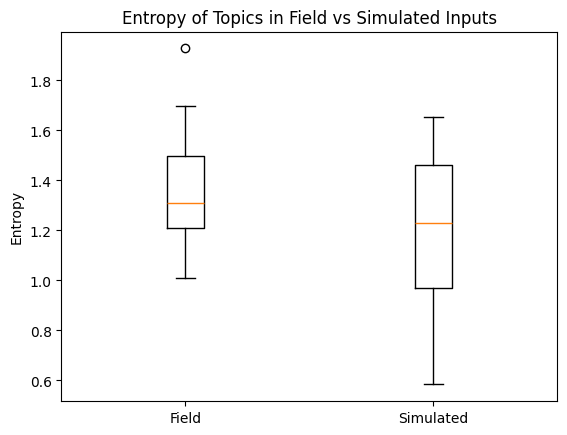

/var/folders/k_/n9gdj4xd2qjb7n7d7399r5dm0000gn/T/ipykernel_28995/1432088537.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



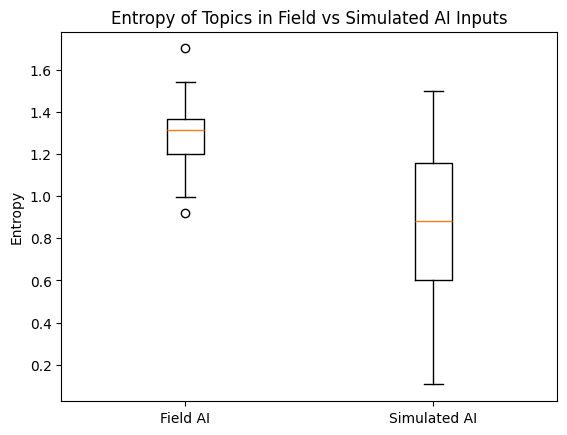

In [ ]:
#Entropy measures how evenly the story spreads across its active topics. A one-topic story has entropy = 0; a perfectly 5-way split has entropy = log 5.
plt.boxplot([entropy_scores_field, entropy_scores_sim], labels=["Field", "Simulated"])
plt.title("Entropy of Topics in Field vs Simulated Stories")
plt.ylabel("Entropy")
plt.show()

plt.boxplot([entropy_scores_field_ai, entropy_scores_sim_ai], labels=["Field AI", "Simulated AI"])
plt.title("Entropy of Topics in Field vs Simulated AI Inputs")
plt.ylabel("Entropy")
plt.show()

#### Jensen-Shannon divergence

Mean JS within field: 0.465
Mean JS within sim  : 0.540
Mean JS within field AI: 0.483
Mean JS within simulated AI: 0.700


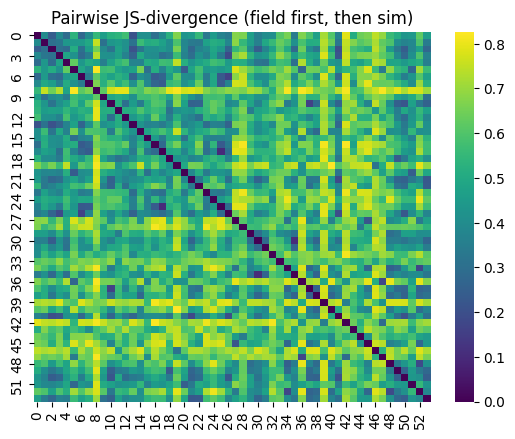

In [ ]:
mean_js_within_field = np.mean(js_within_field)
mean_js_within_sim = np.mean(js_within_sim)

print(f"Mean JS within field: {mean_js_within_field:.3f}")
print(f"Mean JS within sim  : {mean_js_within_sim:.3f}")
print(f"Mean JS within field AI: {mean_js_within_field_ai:.3f}")
print(f"Mean JS within simulated AI: {mean_js_within_ai_sim:.3f}")

all_P = np.vstack([P_field, P_sim])
N = all_P.shape[0]
js_mat = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        d = jensenshannon(all_P[i], all_P[j])
        js_mat[i, j] = js_mat[j, i] = d

sns.heatmap(js_mat, cmap="viridis")
plt.title("Pairwise JS-divergence (field first, then sim)")
plt.show()

In [ ]:
# Compute means for each metric and store in a DataFrame
df_meaned_metrics = pd.DataFrame({
    "field_metrics": {"breadth": breadth_field.mean(),
        "entropy": entropy_scores_field.mean(),
        "js_within": mean_js_within_field,
        "breadth_ai": breadth_field_ai.mean(),
        "entropy_ai": entropy_scores_field_ai.mean(),
        "js_within_ai": mean_js_within_field_ai},
    "sim_metrics": {"breadth": breadth_sim.mean(),
        "entropy": entropy_scores_sim.mean(),
        "js_within": mean_js_within_sim,
        "breadth_ai": breadth_sim_ai.mean(),
        "entropy_ai": entropy_scores_sim_ai.mean(),
        "js_within_ai": mean_js_within_ai_sim}
})

NameError: name 'pd' is not defined